**Assignment 1: Single Layer Perceptron**

## 1. Import Library dan Membaca Spreadsheet

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "/content/Deep Learning Assignment 1 SLP - Giganius Revo.xlsx"

training_sheet = pd.read_excel(
    FILE_PATH,
    sheet_name="SLP-Training",
    header=None
)

validation_sheet = pd.read_excel(
    FILE_PATH,
    sheet_name="SLP-Validation",
    header=None
)

print("File berhasil dibaca.")

File berhasil dibaca.


## 2. Menyiapkan Data dan Parameter Model

In [34]:

LEARNING_RATE = 0.1
EPOCHS = 5
INITIAL_BIAS = 0.5
INITIAL_THETA = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)
THRESHOLD = 0.5


train_raw = training_sheet.iloc[4:84, 2:7].copy()

train_raw.columns = [
    "X1",
    "X2",
    "X3",
    "X4",
    "Target"
]

train_raw = train_raw.astype(float)

X_train = train_raw[
    ["X1", "X2", "X3", "X4"]
].to_numpy()

y_train = train_raw[
    "Target"
].to_numpy()


validation_raw = validation_sheet.iloc[6:26, 2:7].copy()

validation_raw.columns = [
    "X1",
    "X2",
    "X3",
    "X4",
    "Target"
]

validation_raw = validation_raw.astype(float)

X_validation = validation_raw[
    ["X1", "X2", "X3", "X4"]
].to_numpy()

y_validation = validation_raw[
    "Target"
].to_numpy()


print("Training data   :", X_train.shape)
print("Validation data :", X_validation.shape)

Training data   : (80, 4)
Validation data : (20, 4)


## 3. Mendefinisikan Fungsi Single Layer Perceptron

In [35]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def predict_class(output):
    return 1 if output > THRESHOLD else 0


def calculate_gradient(output, target, x):
    error = output - target

    sigmoid_derivative = (
        output * (1 - output)
    )

    dbias = (
        2
        * error
        * sigmoid_derivative
    )

    dtheta = (
        dbias * x
    )

    return dbias, dtheta

## 4. Training Single Layer Perceptron

In [36]:
def train_slp(
    X,
    y,
    epochs,
    learning_rate,
    initial_bias,
    initial_theta
):

    bias = float(initial_bias)
    theta = initial_theta.copy().astype(float)

    history = []
    validation_weights = []


    for epoch in range(1, epochs + 1):

        losses = []
        predictions = []


        for i in range(len(X)):

            x = X[i]
            target = y[i]


            bias_before = bias
            theta_before = theta.copy()

            z = bias + np.dot(theta, x)
            output = sigmoid(z)

            prediction = predict_class(output)

            error = output - target
            loss = error ** 2

            dbias, dtheta = calculate_gradient(
                output,
                target,
                x
            )

            losses.append(loss)
            predictions.append(prediction)

            if i == len(X) - 1:
                validation_weights.append({
                    "epoch": epoch,
                    "bias": bias_before,
                    "theta": theta_before.copy()
                })

            bias -= learning_rate * dbias
            theta -= learning_rate * dtheta


        predictions = np.array(predictions)

        mse = np.mean(losses)

        accuracy = np.mean(
            predictions == y
        )

        history.append({
            "Epoch": epoch,
            "MSE": mse,
            "Accuracy": accuracy
        })


    return (
        pd.DataFrame(history),
        validation_weights
    )


training_summary, validation_weights = train_slp(
    X=X_train,
    y=y_train,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    initial_bias=INITIAL_BIAS,
    initial_theta=INITIAL_THETA
)

display(training_summary)

,Epoch,MSE,Accuracy
0,1,0.4498886551,0.5250
1,2,0.0374519142,0.9500
2,3,0.0243721950,0.9750
3,4,0.0173572017,0.9750
4,5,0.0127401582,0.9875


## 5. Validation Single Layer Perceptron

In [37]:
def validate_slp(
    X,
    y,
    validation_weights,
    learning_rate
):

    history = []


    for weight_info in validation_weights:

        epoch = weight_info["epoch"]

        bias = float(
            weight_info["bias"]
        )

        theta = (
            weight_info["theta"]
            .copy()
            .astype(float)
        )

        losses = []
        predictions = []


        for i in range(len(X)):

            x = X[i]
            target = y[i]

            z = bias + np.dot(theta, x)
            output = sigmoid(z)

            prediction = predict_class(output)


            error = output - target
            loss = error ** 2

            dbias, dtheta = calculate_gradient(
                output,
                target,
                x
            )

            losses.append(loss)
            predictions.append(prediction)


            bias -= learning_rate * dbias
            theta -= learning_rate * dtheta


        predictions = np.array(predictions)

        mse = np.mean(losses)

        accuracy = np.mean(
            predictions == y
        )

        history.append({
            "Epoch": epoch,
            "MSE": mse,
            "Accuracy": accuracy
        })


    return pd.DataFrame(history)


validation_summary = validate_slp(
    X=X_validation,
    y=y_validation,
    validation_weights=validation_weights,
    learning_rate=LEARNING_RATE
)

display(validation_summary)

,Epoch,MSE,Accuracy
0,1,0.0996779577,0.85
1,2,0.0648500822,0.90
2,3,0.0456473539,0.95
3,4,0.0345154827,1.00
4,5,0.0277137819,1.00


## 6. Hasil, Visualisasi, dan Validasi

,Epoch,Training MSE,Validation MSE,Training Accuracy,Validation Accuracy
0,1,0.4498886551,0.0996779577,0.5250,0.85
1,2,0.0374519142,0.0648500822,0.9500,0.90
2,3,0.0243721950,0.0456473539,0.9750,0.95
3,4,0.0173572017,0.0345154827,0.9750,1.00
4,5,0.0127401582,0.0277137819,0.9875,1.00


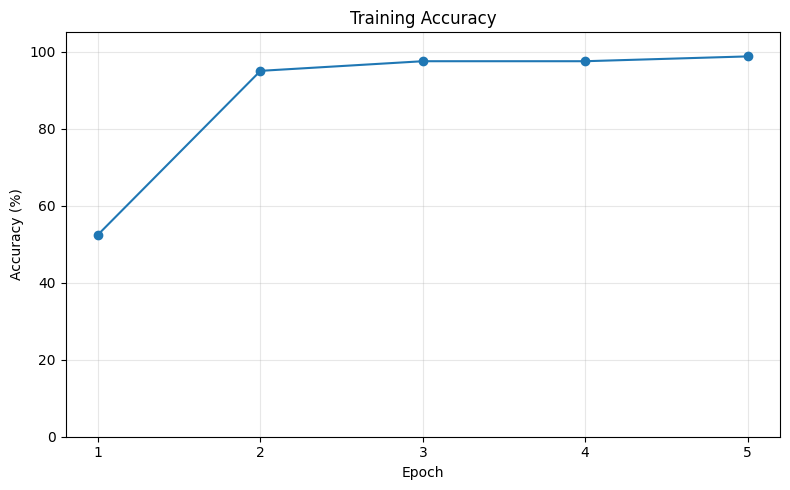

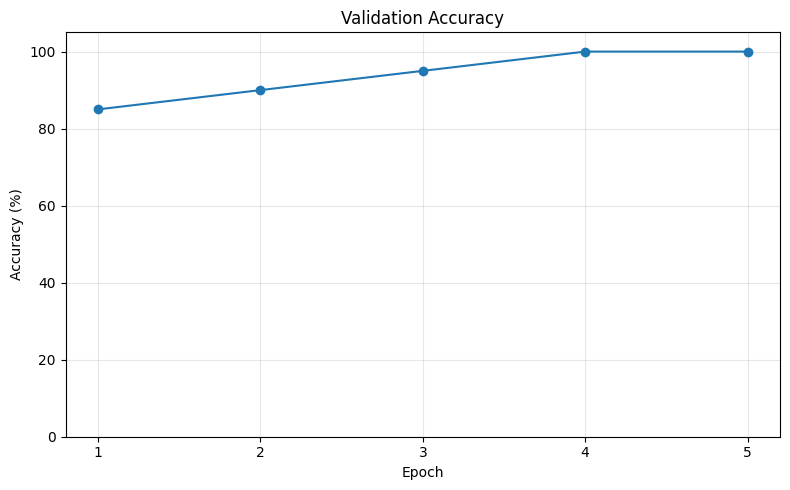

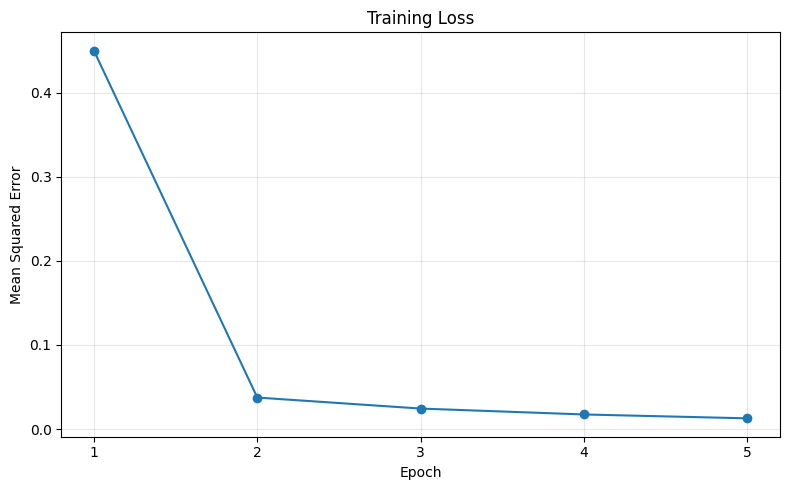

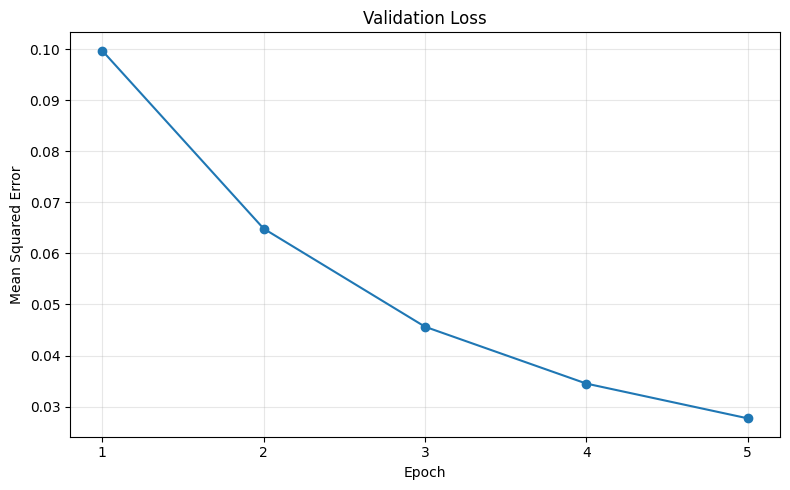

=== VALIDASI DENGAN SPREADSHEET ===
Training MSE       : True
Training Accuracy  : True
Validation MSE     : True
Validation Accuracy: True


In [39]:


result = pd.DataFrame({
    "Epoch": training_summary["Epoch"],
    "Training MSE": training_summary["MSE"],
    "Validation MSE": validation_summary["MSE"],
    "Training Accuracy": training_summary["Accuracy"],
    "Validation Accuracy": validation_summary["Accuracy"]
})

display(result)




plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Training Accuracy"] * 100,
    marker="o"
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(result["Epoch"])
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Validation Accuracy"] * 100,
    marker="o"
)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(result["Epoch"])
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Training MSE"],
    marker="o"
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.xticks(result["Epoch"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




plt.figure(figsize=(8, 5))

plt.plot(
    result["Epoch"],
    result["Validation MSE"],
    marker="o"
)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.xticks(result["Epoch"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




sheet_training_mse = np.array([
    0.4498886551,
    0.03745191423,
    0.024372195,
    0.01735720168,
    0.01274015821
])

sheet_training_accuracy = np.array([
    0.525,
    0.95,
    0.975,
    0.975,
    0.9875
])

sheet_validation_mse = np.array([
    0.09967795771,
    0.06485008221,
    0.04564735393,
    0.03451548273,
    0.02771378188
])

sheet_validation_accuracy = np.array([
    0.85,
    0.90,
    0.95,
    1.00,
    1.00
])


print("=== VALIDASI DENGAN SPREADSHEET ===")

print(
    "Training MSE       :",
    np.allclose(
        training_summary["MSE"],
        sheet_training_mse
    )
)

print(
    "Training Accuracy  :",
    np.allclose(
        training_summary["Accuracy"],
        sheet_training_accuracy
    )
)

print(
    "Validation MSE     :",
    np.allclose(
        validation_summary["MSE"],
        sheet_validation_mse
    )
)

print(
    "Validation Accuracy:",
    np.allclose(
        validation_summary["Accuracy"],
        sheet_validation_accuracy
    )
)